<a href="https://colab.research.google.com/github/souricebunny/NeuroMarketing/blob/main/colgatead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"
!pip install torchaudio==2.6.0 --force-reinstall --quiet

Using Python 3.12.13 environment at: /usr
Resolved 138 packages in 719ms
Uninstalled 15 packages in 633ms
Installed 15 packages in 393ms
 - nvidia-cublas-cu12==12.1.3.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.1.105
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.1.105
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.1.105
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==8.9.2.26
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.0.2.54
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.2.106
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-cu12==11.4.5.107
 + nvidia-cusolver-cu12==11.6.1.9
 - nvidia-cusparse-cu12==12.1.0.106
 + nvidia-cusparse-cu12==12.3.1.170
 - nvidia-nccl-cu12==2.19.3
 + nvidia-nccl-cu12==2.21.5
 - nvidia-nvjitlink-cu12==12.9.86
 + nvidia-nvjitlink-cu12==12.4.127
 - nvidia-nvtx-cu12==12.1.105
 + nvidia-nvtx-cu12==12.4.127
 - sympy==1.14.0
 + sympy==1.13.1
 - torch==2.2.0
 + torch=

In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-06-29 06:59:36 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-06-29 06:59:40 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set trea

In [8]:
from google.colab import files
uploaded = files.upload()
# Upload your Colgate ad here

Saving Colgate Visible White Purple  The Beauty Secret  Hindi - Colgate India (360p, h264, youtube).mp4 to Colgate Visible White Purple  The Beauty Secret  Hindi - Colgate India (360p, h264, youtube) (1).mp4


In [9]:
video_path = "/content/Colgate Visible White Purple  The Beauty Secret  Hindi - Colgate India (360p, h264, youtube).mp4"

df = model.get_events_dataframe(video_path=video_path)
df = df[df['type'].isin(['Video', 'Audio'])].reset_index(drop=True)
df = df[df['start'] <= 10].reset_index(drop=True)

print(f"Total events: {len(df)}")
print(df['type'].value_counts())
display(df.head(8)[["type", "start", "duration"]])

Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 2293.22it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 57.88it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This i

Total events: 2
type
Audio    1
Video    1
Name: count, dtype: int64


,type,start,duration
0,Audio,0.0,20.13
1,Video,0.0,20.13


In [10]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[07:39:48 WARNING] Removing extractor text as there are no corresponding events
[07:39:48 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


config.json:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[07:40:14 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

2026-06-29 07:41:10 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 20.13s at 25.0fps, shape (640, 360)):
/content/Colgate Visible White Purple  The Beauty Secret  Hindi - Colgate India (360p, h264, youtube).mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 20.13s at 25.0fps, shape (640, 360)):
/content/Colgate Visible White Purple  The Beauty Secret  Hindi - Colgate India (360p, h264, youtube).mp4
Encoding video:   0%|          | 0/40 [00:00<?, ?it/s]2026-06-29 07:41:26 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (40, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (40, 20, 1408)
Encoding video: 100%|██████████| 40/40 [11:14<00:00, 16.86s/it]
[07:52:25 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-06-29 07:52:25 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:52:25 INFO] Building datal

Predictions shape: (21, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.08it/s]


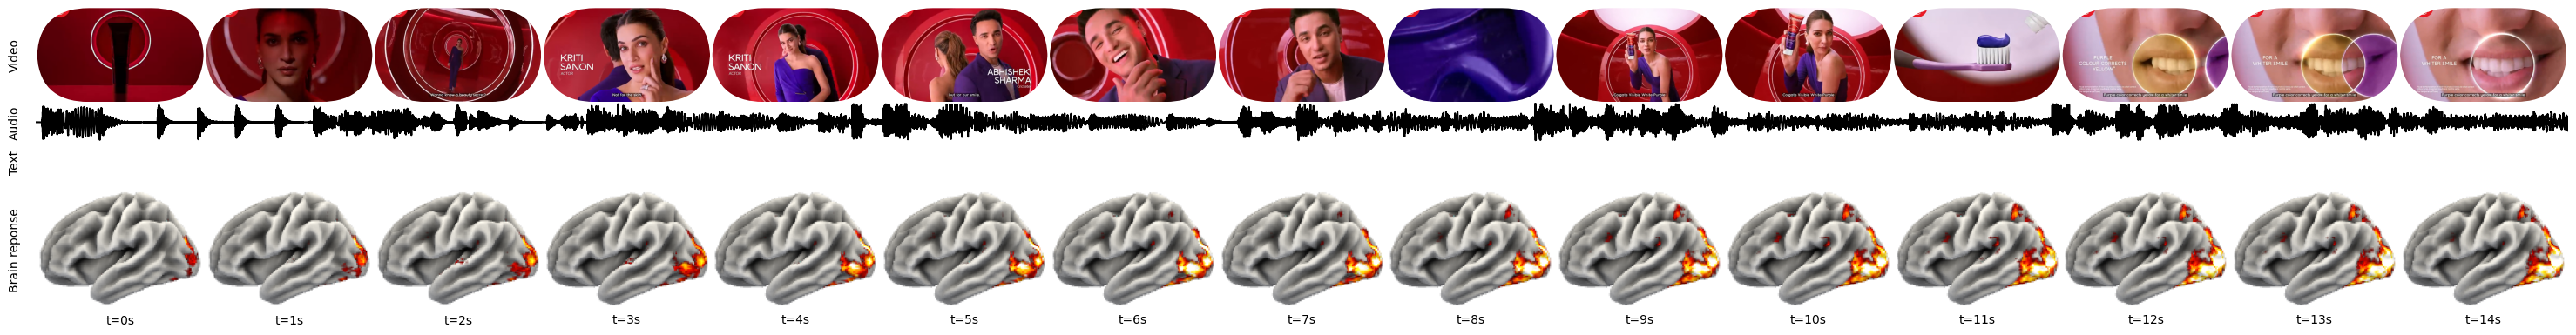

In [12]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)